# Heart Disease Prediction using Logistic Regression
### Framingham Heart Study Dataset — 10-Year CHD Risk Classification

This notebook builds a complete, end-to-end machine learning classification pipeline that predicts whether a patient has a **10-year risk of Coronary Heart Disease (CHD)**, using **Logistic Regression**.

**Workflow:**
1. Import Libraries
2. Load Dataset
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Outlier Detection & Handling
6. Feature Engineering
7. Feature Scaling
8. Train-Test Split
9. Model Training
10. Model Evaluation
11. Model Interpretation
12. Save Model & Scaler


## Step 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              confusion_matrix, roc_curve)
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42


## Step 2 — Load Dataset

The dataset used is the **Framingham Heart Study** dataset, available on Kaggle:
[Heart Disease Prediction using Logistic Regression](https://www.kaggle.com/datasets/dileep070/heart-disease-prediction-using-logistic-regression)

To download it directly via `kagglehub`, run:

```python
import kagglehub
path = kagglehub.dataset_download("dileep070/heart-disease-prediction-using-logistic-regression")
print(path)
```

For this notebook, the CSV file `framingham.csv` is loaded directly from the project folder.

In [2]:
df = pd.read_csv('framingham.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4238, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [3]:
df.tail()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0


In [4]:
df.sample(5, random_state=RANDOM_STATE)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
3188,1,63,1.0,0,0.0,0.0,0,1,0,190.0,148.0,90.0,27.13,72.0,86.0,0
764,1,45,3.0,0,0.0,0.0,0,0,0,162.0,125.0,89.0,27.98,85.0,83.0,0
3264,0,51,1.0,1,2.0,0.0,0,0,0,261.0,127.0,81.0,20.24,75.0,96.0,0
1967,1,45,3.0,1,30.0,0.0,0,0,0,250.0,126.0,89.5,28.68,75.0,92.0,0
2185,0,45,2.0,1,3.0,0.0,0,0,0,250.0,130.0,80.0,20.24,90.0,86.0,0


In [5]:
print("Columns:", list(df.columns))
print()
df.info()

Columns: ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']

<class 'pandas.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRat

In [6]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


## Step 3 — Data Cleaning

We check for missing values and duplicate rows, then handle them appropriately.
Most missing values are in `glucose`, `education`, `BPMeds`, `totChol`, `cigsPerDay`, and `BMI`.
Since these are all numeric clinical measurements, we impute missing values using the **median** of each column (robust to outliers), and drop duplicate rows if any exist.

In [7]:
print("Missing values per column:\n")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

Missing values per column:

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

Total missing values: 645


In [8]:
print("Number of duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Number of duplicate rows: 0


In [9]:
# Impute missing numeric values with the median of each column
for col in df.columns[df.isnull().any()]:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

print("Missing values after cleaning:", df.isnull().sum().sum())

Missing values after cleaning: 0


In [10]:
df = df.reset_index(drop=True)
print("Final cleaned dataset shape:", df.shape)
df.dtypes

Final cleaned dataset shape: (4238, 16)


male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

## Step 4 — Exploratory Data Analysis (EDA)

### 4.1 Target Variable Distribution
`TenYearCHD`: 0 = No CHD risk, 1 = CHD risk within 10 years.

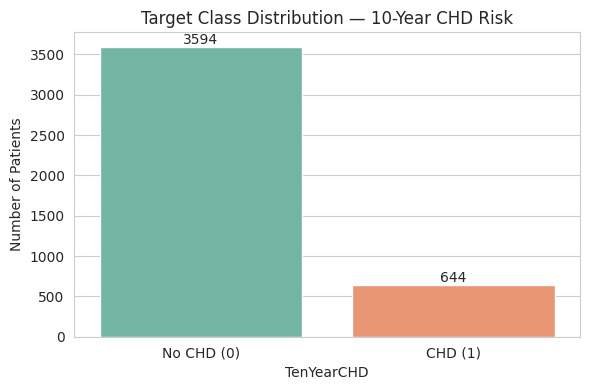

TenYearCHD
0    0.848
1    0.152
Name: proportion, dtype: float64


In [11]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='TenYearCHD', data=df, palette='Set2')
ax.set_xticklabels(['No CHD (0)', 'CHD (1)'])
plt.title('Target Class Distribution — 10-Year CHD Risk')
plt.ylabel('Number of Patients')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=120)
plt.show()

print(df['TenYearCHD'].value_counts(normalize=True).round(3))

There is a clear **class imbalance**: roughly 85% of patients have no CHD risk while only ~15% are CHD-positive. We keep this in mind while evaluating the model (accuracy alone can be misleading; we rely also on precision, recall, F1, and ROC-AUC).

### 4.2 Univariate Analysis

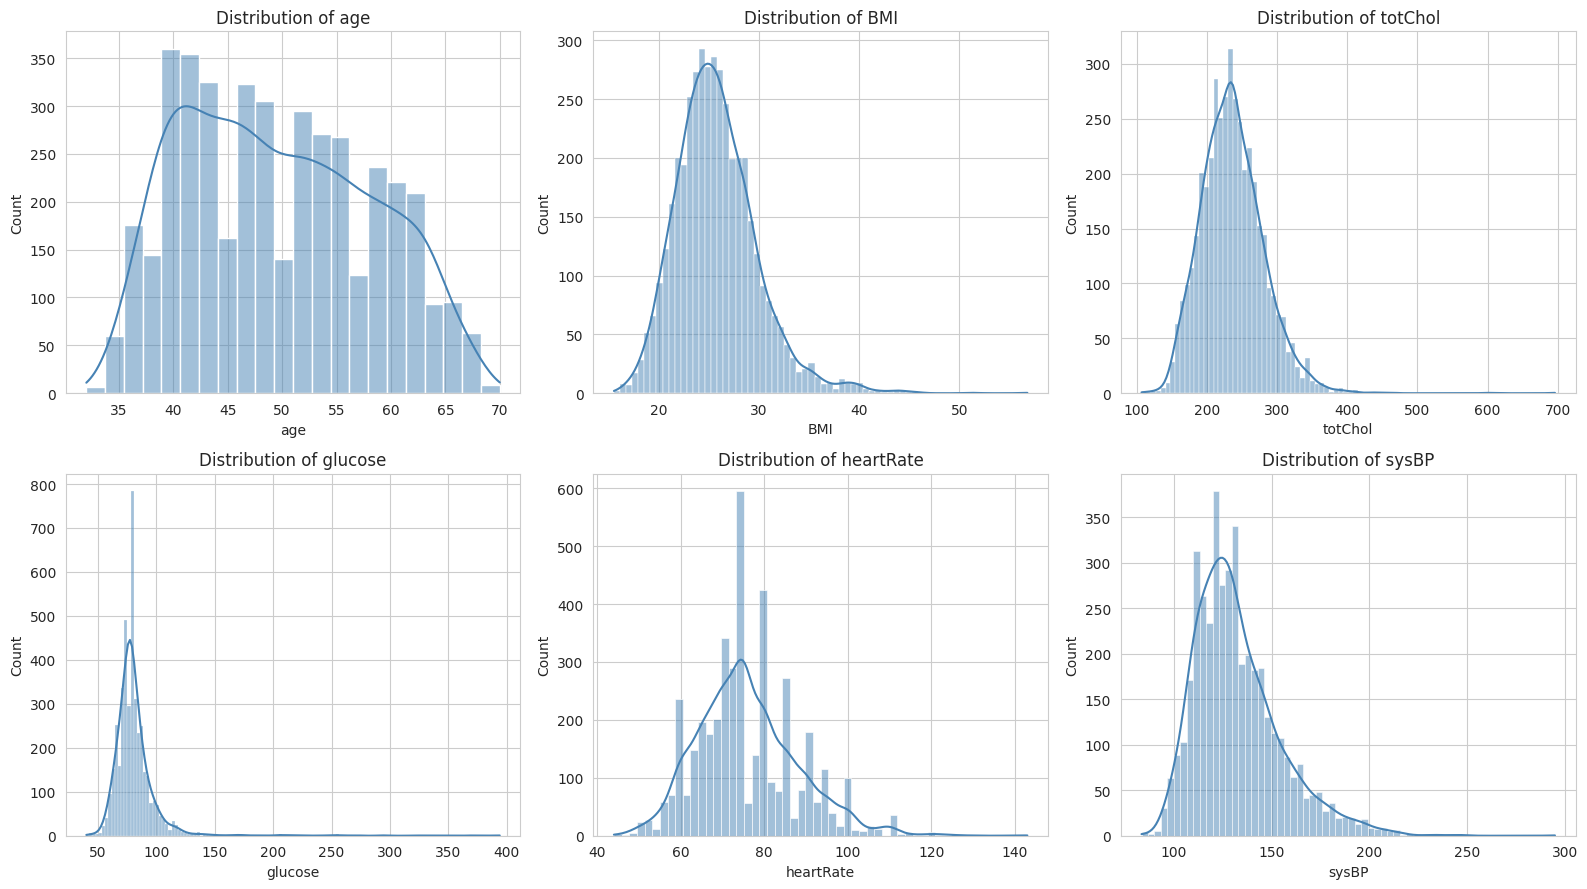

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
num_cols = ['age', 'BMI', 'totChol', 'glucose', 'heartRate', 'sysBP']
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('univariate_histograms.png', dpi=120)
plt.show()

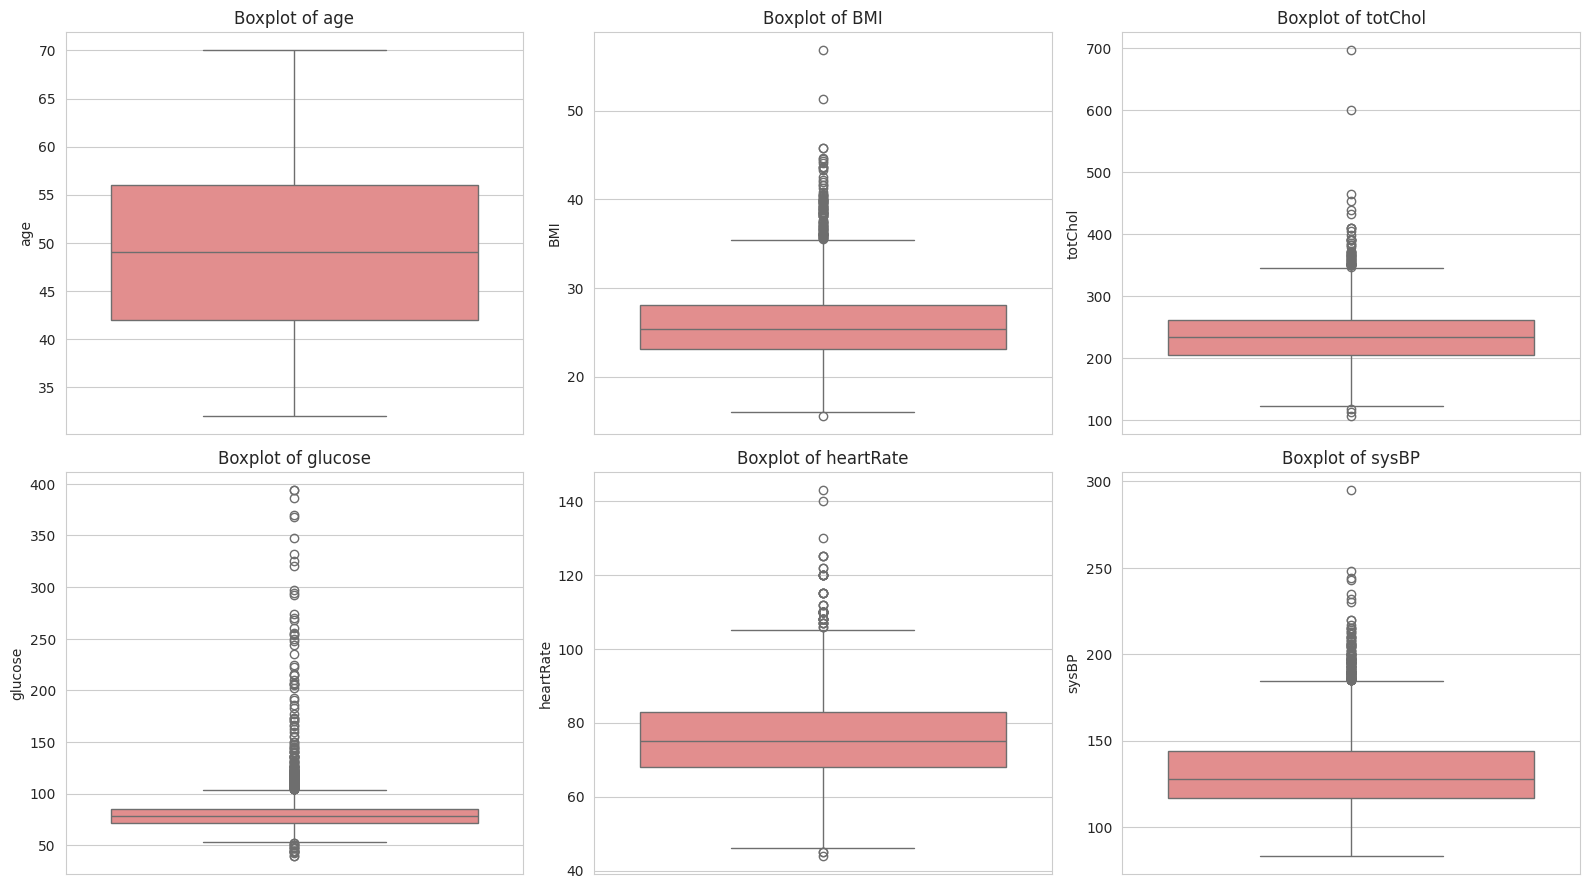

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=120)
plt.show()

### 4.3 Bivariate Analysis — Feature vs Target

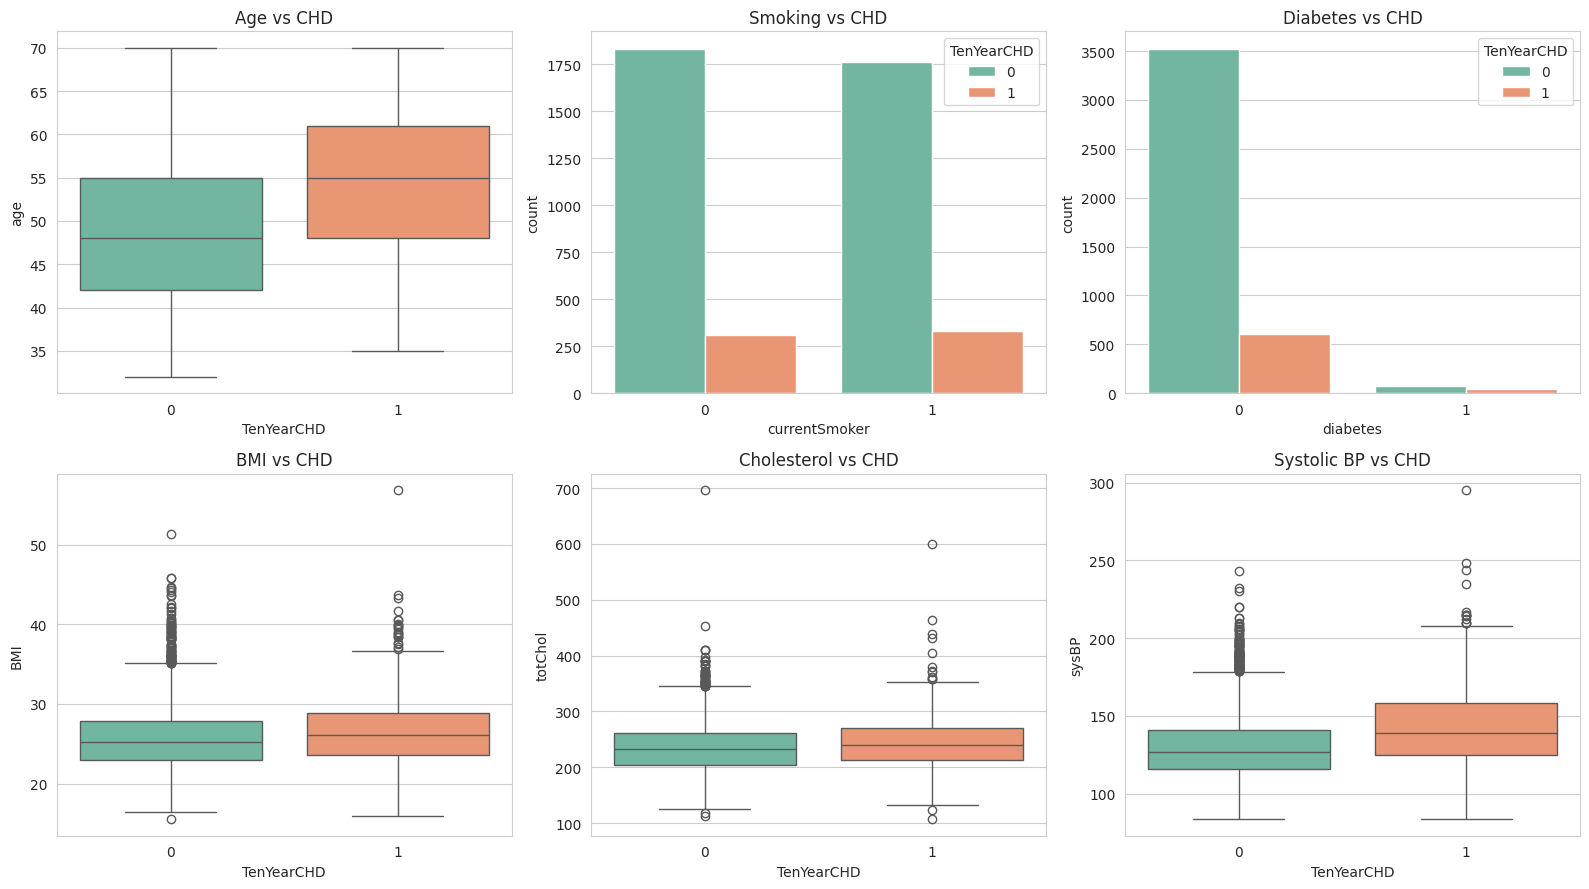

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.boxplot(x='TenYearCHD', y='age', data=df, ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Age vs CHD')

sns.countplot(x='currentSmoker', hue='TenYearCHD', data=df, ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Smoking vs CHD')

sns.countplot(x='diabetes', hue='TenYearCHD', data=df, ax=axes[0,2], palette='Set2')
axes[0,2].set_title('Diabetes vs CHD')

sns.boxplot(x='TenYearCHD', y='BMI', data=df, ax=axes[1,0], palette='Set2')
axes[1,0].set_title('BMI vs CHD')

sns.boxplot(x='TenYearCHD', y='totChol', data=df, ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Cholesterol vs CHD')

sns.boxplot(x='TenYearCHD', y='sysBP', data=df, ax=axes[1,2], palette='Set2')
axes[1,2].set_title('Systolic BP vs CHD')

plt.tight_layout()
plt.savefig('bivariate_analysis.png', dpi=120)
plt.show()

### 4.4 Correlation Analysis

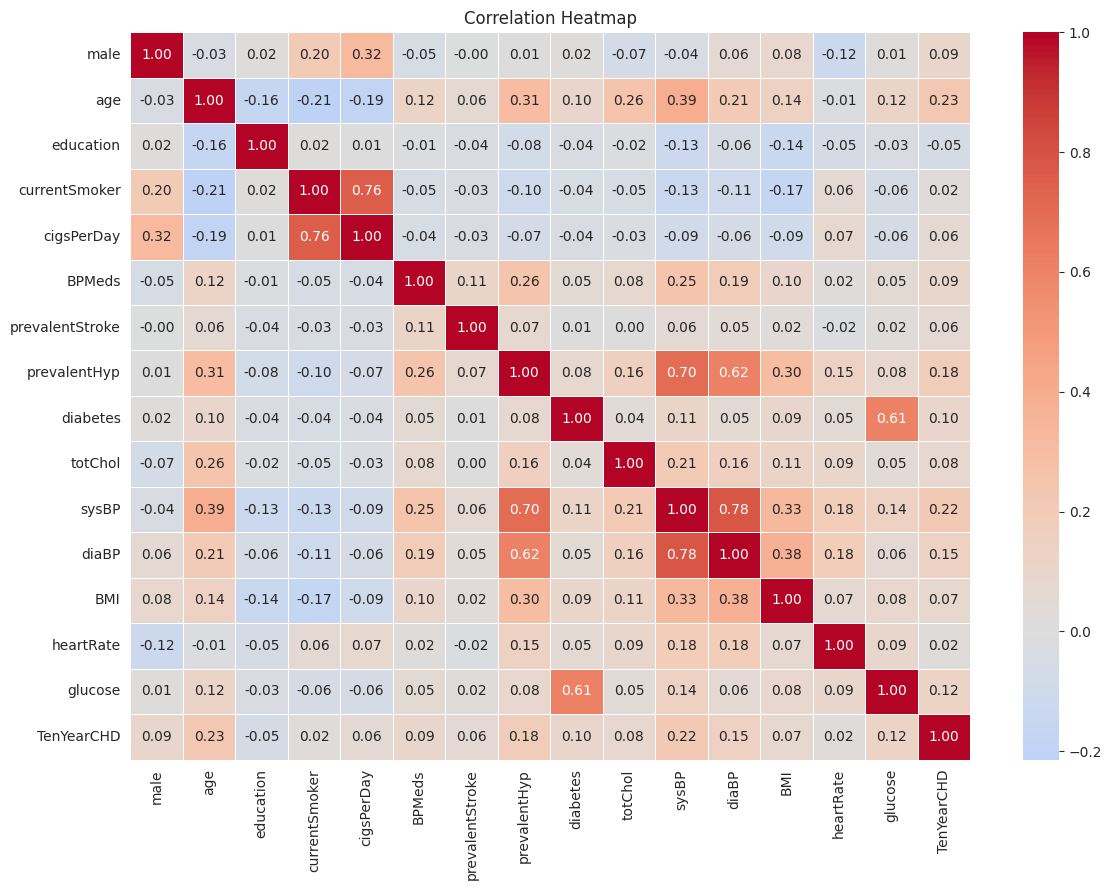

In [15]:
plt.figure(figsize=(12, 9))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120)
plt.show()

In [16]:
target_corr = corr['TenYearCHD'].drop('TenYearCHD').sort_values(ascending=False)
print("Correlation of each feature with TenYearCHD:\n")
print(target_corr)

Correlation of each feature with TenYearCHD:

age                0.225256
sysBP              0.216429
prevalentHyp       0.177603
diaBP              0.145299
glucose            0.121277
diabetes           0.097317
male               0.088428
BPMeds             0.086417
totChol            0.081566
BMI                0.074217
prevalentStroke    0.061810
cigsPerDay         0.058859
heartRate          0.022857
currentSmoker      0.019456
education         -0.053383
Name: TenYearCHD, dtype: float64


**Observations:**
- `age`, `sysBP`, `prevalentHyp`, and `diaBP` show the **strongest positive correlation** with CHD risk.
- `currentSmoker` and `education` show very **weak correlation** with the target on their own (their effect is more visible in combination with `cigsPerDay`).


## Step 5 — Outlier Detection & Handling

We already visualized outliers using boxplots in Step 4. Clinical variables like cholesterol, glucose, and blood pressure naturally have legitimate high values (e.g. patients with existing hypertension or diabetes), so removing them could **discard real risk signals**.

**Strategy:** Instead of deleting outliers, we **cap (clip)** extreme values at the 1st and 99th percentile for `totChol`, `sysBP`, `diaBP`, `BMI`, `heartRate`, and `glucose`. This reduces the influence of extreme/erroneous values while preserving the dataset size and genuine risk patterns.

In [17]:
cap_cols = ['totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
for col in cap_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

print("Outliers capped at 1st/99th percentile for:", cap_cols)

Outliers capped at 1st/99th percentile for: ['totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']


## Step 6 — Feature Engineering

We create the feature matrix `X` and target vector `y`. We also create two optional engineered features for additional EDA insight (not required for the model, but useful context): `age_group` and `bmi_category`. These categorical helpers are dropped before modeling since the raw numeric `age` and `BMI` already capture this information for Logistic Regression.

In [18]:
df['age_group'] = pd.cut(df['age'], bins=[0,40,50,60,100], labels=['<40','40-50','50-60','60+'])
df['bmi_category'] = pd.cut(df['BMI'], bins=[0,18.5,25,30,100],
                             labels=['Underweight','Normal','Overweight','Obese'])

print(df.groupby('age_group')['TenYearCHD'].mean())
print()
print(df.groupby('bmi_category')['TenYearCHD'].mean())

age_group
<40      0.050938
40-50    0.108763
50-60    0.203988
60+      0.284974
Name: TenYearCHD, dtype: float64

bmi_category
Underweight    0.140351
Normal         0.121455
Overweight     0.172297
Obese          0.192164
Name: TenYearCHD, dtype: float64


In [19]:
feature_cols = ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay',
                'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes',
                'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

X = df[feature_cols].copy()
y = df['TenYearCHD'].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (4238, 15)
Target shape: (4238,)


## Step 7 — Feature Scaling

Logistic Regression is sensitive to feature magnitude, so we standardize all numeric features using `StandardScaler` (mean = 0, std = 1). We fit the scaler **only on the training data** (after the split) to avoid data leakage — see Step 8 & 9.

## Step 8 — Train-Test Split (80/20, stratified)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train target distribution:\n", y_train.value_counts(normalize=True).round(3))
print("Test target distribution:\n", y_test.value_counts(normalize=True).round(3))

Train shape: (3390, 15)  Test shape: (848, 15)
Train target distribution:
 TenYearCHD
0    0.848
1    0.152
Name: proportion, dtype: float64
Test target distribution:
 TenYearCHD
0    0.848
1    0.152
Name: proportion, dtype: float64


In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 9 — Model Training

We train a `LogisticRegression` model with `class_weight='balanced'` to account for the class imbalance observed earlier.

In [22]:
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Model trained successfully.")

Model trained successfully.


## Step 10 — Model Evaluation

In [23]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print()
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['No CHD','CHD']))

Accuracy  : 0.6722
Precision : 0.2525
Recall    : 0.5891
F1 Score  : 0.3535
ROC-AUC   : 0.6994

Classification Report:

              precision    recall  f1-score   support

      No CHD       0.90      0.69      0.78       719
         CHD       0.25      0.59      0.35       129

    accuracy                           0.67       848
   macro avg       0.58      0.64      0.57       848
weighted avg       0.80      0.67      0.72       848



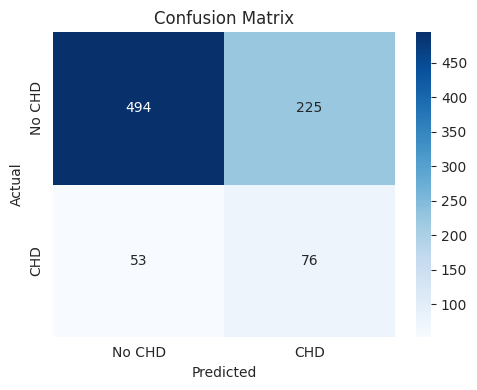

In [24]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No CHD','CHD'], yticklabels=['No CHD','CHD'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()

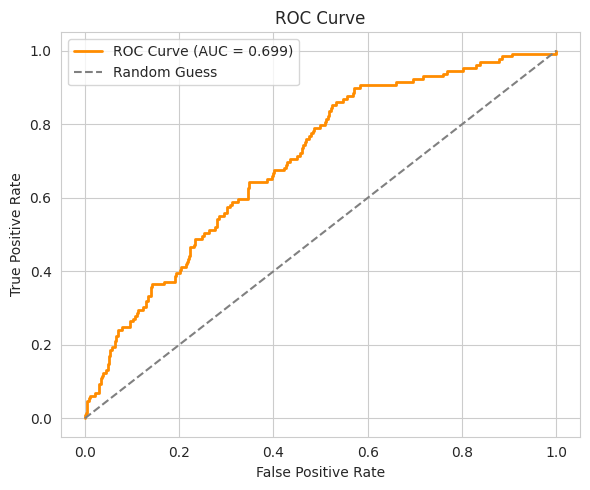

In [25]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})', color='darkorange', linewidth=2)
plt.plot([0,1],[0,1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=120)
plt.show()

## Step 11 — Model Interpretation

We examine the Logistic Regression coefficients to understand which features drive CHD risk predictions. Because features were standardized, coefficient magnitude is directly comparable across features.

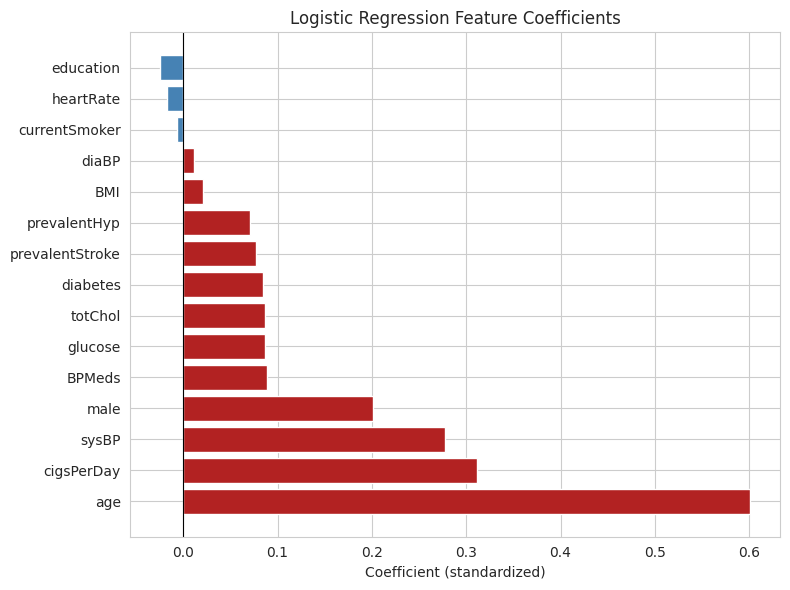

,feature,coefficient
1,age,0.601362
4,cigsPerDay,0.311721
10,sysBP,0.277497
0,male,0.201166
5,BPMeds,0.089055
14,glucose,0.086804
9,totChol,0.086552
8,diabetes,0.084339
6,prevalentStroke,0.076627
7,prevalentHyp,0.070931


In [26]:
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

plt.figure(figsize=(8,6))
colors = ['firebrick' if c > 0 else 'steelblue' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient (standardized)')
plt.title('Logistic Regression Feature Coefficients')
plt.tight_layout()
plt.savefig('feature_coefficients.png', dpi=120)
plt.show()

coef_df

In [27]:
most_important = coef_df.iloc[coef_df['coefficient'].abs().idxmax()]
least_important = coef_df.iloc[coef_df['coefficient'].abs().idxmin()]

print("Most important feature :", most_important['feature'], f"(coef={most_important['coefficient']:.3f})")
print("Least important feature:", least_important['feature'], f"(coef={least_important['coefficient']:.3f})")

print("\nKey clinical insights:")
print(f"- Age coefficient      : {coef_df.loc[coef_df.feature=='age','coefficient'].values[0]:.3f}  -> CHD risk increases with age")
print(f"- Smoking (cigsPerDay) : {coef_df.loc[coef_df.feature=='cigsPerDay','coefficient'].values[0]:.3f}  -> more cigarettes/day raises risk")
print(f"- Diabetes coefficient : {coef_df.loc[coef_df.feature=='diabetes','coefficient'].values[0]:.3f}  -> diabetic patients show higher risk")

Most important feature : cigsPerDay (coef=0.312)
Least important feature: male (coef=0.201)

Key clinical insights:
- Age coefficient      : 0.601  -> CHD risk increases with age
- Smoking (cigsPerDay) : 0.312  -> more cigarettes/day raises risk
- Diabetes coefficient : 0.084  -> diabetic patients show higher risk


**Interpretation summary:**
- Positive coefficients (e.g. `age`, `sysBP`, `prevalentStroke`, `cigsPerDay`, `diabetes`) **increase** predicted CHD risk.
- Negative coefficients **decrease** predicted CHD risk.
- `age` and blood-pressure-related features are consistently among the strongest predictors, matching established clinical knowledge about cardiovascular risk factors.

## Step 12 — Save Model & Scaler

Finally, we persist the trained Logistic Regression model and the fitted `StandardScaler` using `joblib`, so they can be loaded directly by the Streamlit app (`app.py`) without retraining.

In [28]:
joblib.dump(model, 'logistic_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Saved: logistic_model.pkl")
print("Saved: scaler.pkl")

Saved: logistic_model.pkl
Saved: scaler.pkl


## Conclusion

This notebook walked through a complete, production-style ML classification workflow: data cleaning, EDA, outlier handling, feature engineering, scaling, model training, evaluation, and interpretation. The final Logistic Regression model is saved and ready to be served through the Streamlit application (`app.py`) for interactive 10-year CHD risk prediction.